In [1]:
import os
from pathlib import Path
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import geodatasets

import rasterio
import rasterio.mask

# Plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

## CODE DESCRIPTION

This notebook generates the first main figure of the paper.

- **Row 1** shows global species richness at 0.5 degree resolution. The taxon rasters are created in `07_postprocess_data/cluster/figure_1/species_richness/` and combined with `combine_global_SR.R`.
- **Row 2** shows the Amazon annual precipitation time series created by `07_postprocess_data/cluster/figure_1/climate_timeseries/figure_1_plot_time_series_ET.py` using the delta approach documented in step 01.
- **Row 3** shows the precipitation difference between tipping and no-tipping scenarios, with the binary BaU deforestation maps created by `07_postprocess_data/local/deforestation_maps/prepare_deforestation_maps.ipynb`.

All local Figure 1 inputs are read from `08_figures/main_figures/figure_1/local/data/` and the rendered figure is written to `output/`.


In [2]:
# Load local Figure 1 data.
working_dir = Path.cwd().resolve()
repository_root = next(
    parent
    for parent in (working_dir, *working_dir.parents)
    if (parent / "08_figures" / "main_figures" / "figure_1" / "local" / "data").is_dir()
)
figure_data_dir = repository_root / "08_figures" / "main_figures" / "figure_1" / "local" / "data"
figure_output_dir = repository_root / "08_figures" / "main_figures" / "figure_1" / "output"
figure_output_dir.mkdir(parents=True, exist_ok=True)

### Row 1: World SR
sr_world_path = figure_data_dir / "SR_world_all_taxa_land_05deg.tif"
with rasterio.open(sr_world_path) as src:
    land = gpd.read_file(geodatasets.get_path("naturalearth.land")).to_crs(src.crs)
    sr_land, _ = rasterio.mask.mask(src, land.geometry, crop=False)

sr_land = sr_land.squeeze().astype(float)

### Row 2: Time series mean annual precipitation in Amazon Basin.
ts_data = pd.read_csv(figure_data_dir / "precipitation_time_series_residET.csv")

### Row 3: spatial dataset of percentage difference between tipping and no-tipping scenario.
period_means = xr.open_dataset(figure_data_dir / "period_means.nc")

# Amazon Basin mask used solely for the pixel-aligned boundary in the maps.
amazon_mask_path = repository_root / "01_climate_data" / "01_c_NorESM2" / "amazon_mask" / "amazon_mask.tif"
with rasterio.open(amazon_mask_path) as src:
    amazon_mask_values = src.read(1)
    amazon_mask_transform = src.transform

# Exact Amazon Basin outline derived directly from the original mask pixels.
# No resampling, closing, or hole filling is applied.
from shapely.geometry import shape

amazon_mask_domain = np.isfinite(amazon_mask_values)
amazon_mask_polygons = [
    shape(geometry)
    for geometry, value in rasterio.features.shapes(
        amazon_mask_domain.astype(np.uint8),
        mask=amazon_mask_domain,
        transform=amazon_mask_transform,
    )
    if value == 1
]
amazon_outline_original = max(amazon_mask_polygons, key=lambda polygon: polygon.area)


C:\Users\Clemens\AppData\Local\Temp\ipykernel_17680\66845823.py:29: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  amazon_mask_values = src.read(1)


In [3]:
# Load local deforestation maps.
defor_folder = figure_data_dir

ds_bin_2030_2044 = xr.open_dataset(defor_folder / "binary_defors_map_2030_2044.nc")
ds_bin_2050_2069 = xr.open_dataset(defor_folder / "binary_defors_map_2050_2069.nc")
ds_bin_2080_2099 = xr.open_dataset(defor_folder / "binary_defors_map_2080_2099.nc")

defor_maps = {
    "2030-2044": ds_bin_2030_2044["deforestation"],
    "2050-2069": ds_bin_2050_2069["deforestation"],
    "2080-2099": ds_bin_2080_2099["deforestation"],
}

# Precompute lon/lat grids for deforestation.
defor_lon = ds_bin_2030_2044.longitude.values
defor_lat = ds_bin_2030_2044.latitude.values
defor_lon2d, defor_lat2d = np.meshgrid(defor_lon, defor_lat)


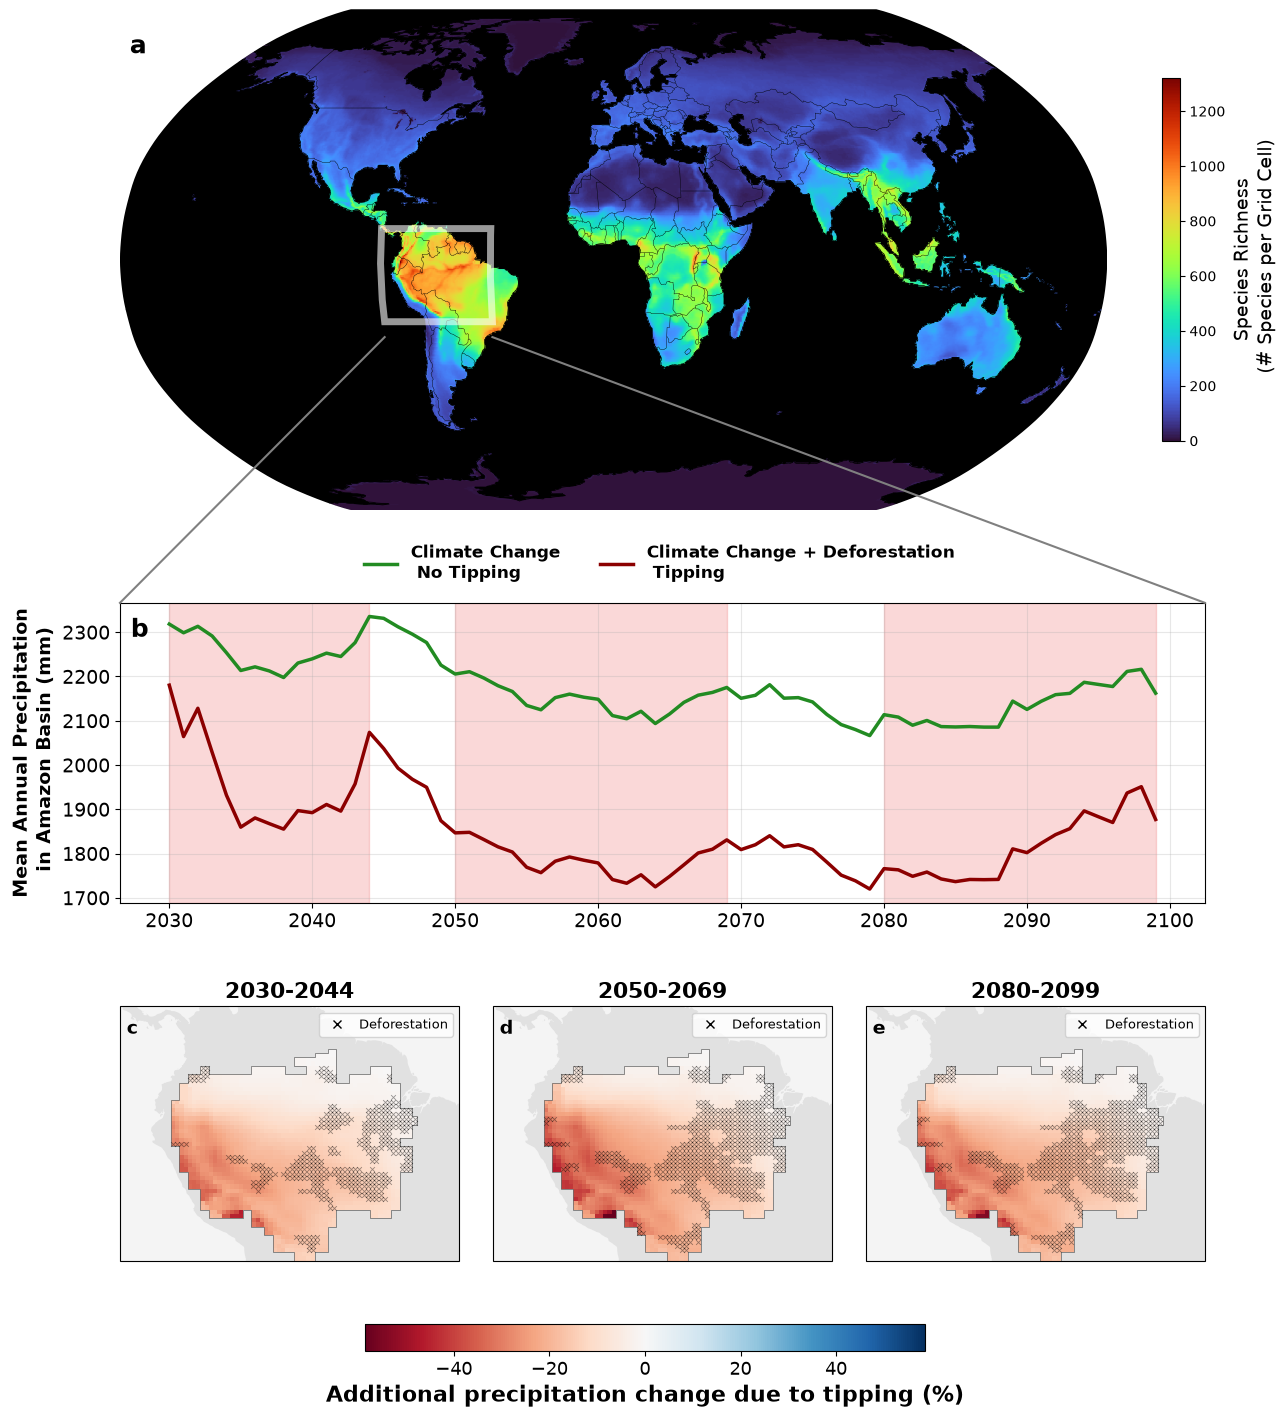

In [4]:
# Create subplots
fig = plt.figure(figsize=(14,18))

proj = ccrs.Robinson()
# proj = ccrs.Mollweide()

data_crs = ccrs.PlateCarree()

gs = GridSpec(
    3, 3,
    height_ratios=[2.5, 1.2, 1.6],
    hspace=0.07,
    wspace=0.1
)

# Define bounding box
bbox = dict(
    lon_min=-85, lon_max=-45,
    lat_min=-20, lat_max=10
)

# Load land borders
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

### Row 1: Global SR plot with bounding box 
ax_sr = fig.add_subplot(gs[0, :], projection=proj)

cmap_sr = plt.cm.turbo.copy()
cmap_sr.set_bad("black")


im_sr = ax_sr.imshow(
    sr_land,
    cmap=cmap_sr,
    extent=[-180, 180, -90, 90],
    origin="upper",
    transform=data_crs 
)

ax_sr.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax_sr.add_feature(cfeature.BORDERS, linewidth=0.3)

rect = mpatches.Rectangle(
    (bbox["lon_min"], bbox["lat_min"]),
    bbox["lon_max"] - bbox["lon_min"],
    bbox["lat_max"] - bbox["lat_min"],
    facecolor="none",
    edgecolor="white",
    linewidth=5,
    alpha=0.6,
    transform=ccrs.PlateCarree(),   
    zorder=10
)
ax_sr.add_patch(rect)

for spine in ax_sr.spines.values():
    spine.set_visible(False)

ax_sr.set_global()

#ax_sr.set_xlabel("Longitude", fontsize=14)
#ax_sr.set_ylabel("Latitude", fontsize=14)
#ax_sr.set_xticks(np.arange(-180,181,60))
#ax_sr.set_yticks(np.arange(-90,91,30))

cbar_sr = fig.colorbar(im_sr, ax=ax_sr, fraction=0.04, pad=0.05, shrink=0.58)
cbar_sr.set_label("Species Richness\n (# Species per Grid Cell)", fontsize=14)


### Row 2: Time series plot
ax_ts = fig.add_subplot(gs[1, :])


shade_specs = [
    (2030, 2044, 'lightcoral'),
    (2050, 2069, 'lightcoral'),
    (2080, 2099, 'lightcoral')
]

for start, end, color in shade_specs:
    ax_ts.axvspan(start, end, color=color, alpha=0.3)

years = ts_data["time"]
ts_no_tip_v = ts_data["ts_no_tip"]
ts_tip_v = ts_data["ts_tip"]

ax_ts.plot(years, ts_no_tip_v,
           label="Climate Change \n No Tipping",
           linewidth=2.5,
           color="forestgreen")

#ax_ts.fill_between(
#    years,
#    ts_tip_ci_low_v,
#    ts_tip_ci_high_v,
#    color="darkred",
#    alpha=0.25,
#    linewidth=0
#)

ax_ts.plot(years, ts_tip_v,
           label="Climate Change + Deforestation \n Tipping",
           linewidth=2.5,
           color="darkred")

ax_ts.grid(alpha=0.3)
ax_ts.set_ylabel("Mean Annual Precipitation\n in Amazon Basin (mm)", fontsize=14, fontweight="bold")
#ax_ts.set_xlabel("Year", fontsize=14)
ax_ts.tick_params(axis='both', labelsize=14)
leg = ax_ts.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    frameon=False,
    fontsize=12
)

for text in leg.get_texts():
    text.set_fontweight("bold")


### Row 3: Spatial map of precentage change

# Set color range
maps = list(period_means.values())
all_vals = np.concatenate([m.values.ravel() for m in maps])
all_vals = all_vals[np.isfinite(all_vals)]

time_periods = ["2030-2044", "2050-2069", "2080-2099"]

vmin = all_vals.min()  
vmax = - vmin
norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

cmap = "RdBu"

lon = period_means[list(period_means.keys())[0]].longitude.values
lat = period_means[list(period_means.keys())[0]].latitude.values
lon2d, lat2d = np.meshgrid(lon, lat)

for i, (label, mean_map) in enumerate(period_means.items()):
    
    # Robison 
    #ax = fig.add_subplot(gs[2, i], projection=proj)
    # Standard
    ax = fig.add_subplot(gs[2, i], projection=ccrs.PlateCarree())

    data = mean_map.values

    ax.set_facecolor("#F4F4F4")
    ax.add_feature(cfeature.OCEAN, facecolor="#F4F4F4", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#E1E1E1", zorder=1)

    im = ax.pcolormesh(
        lon2d, lat2d, data,
        shading="auto",
        cmap=cmap,
        norm=norm,
        transform=data_crs,
        zorder=2)


    # Exact source-mask outline: no resampling or smoothing, so all valid
    # small features of the Amazon Basin boundary are retained.
    outline_x, outline_y = amazon_outline_original.exterior.xy
    ax.plot(
        outline_x, outline_y,
        color="#6B6B6B",
        linewidth=0.55,
        solid_capstyle="butt",
        solid_joinstyle="miter",
        transform=data_crs,
        zorder=4,
    )
    defor = defor_maps[time_periods[i]].values
    mask = defor == 1  

    ax.scatter(
        defor_lon2d[mask],
        defor_lat2d[mask],
        s=12,
        marker="x",
        linewidths=0.6,
        color="black",
        alpha=0.4,
        transform=data_crs,
        zorder=5
    )

    ax.set_extent(
    [bbox["lon_min"], bbox["lon_max"],
     bbox["lat_min"], bbox["lat_max"]],
    crs=data_crs)

    ax.tick_params(labelsize=10)

    if i != 0:
        ax.set_yticks([])
        ax.set_ylabel("")
    
    ax.set_title(time_periods[i], fontsize=16, fontweight="bold")

    legend_handle = Line2D(
        [], [],                    
        marker="x",
        linestyle="None",
        markersize=6,
        markeredgewidth=1.0,
        color="black",
        label="Deforestation")

    ax.legend(
        handles=[legend_handle],
        loc="upper right",
        frameon=True,
        framealpha=0.8,
        fontsize=9)

# Colorbar below
cbar_ax = fig.add_axes([0.3, 0.10, 0.40, 0.015])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.ax.tick_params(labelsize=13)
cbar.set_label("Additional precipitation change due to tipping (%)", fontsize=16, fontweight="bold")


# Add Panel labels
ax_sr.text(0.01, 0.95, "a", transform=ax_sr.transAxes,
           fontsize=18, fontweight="bold", va="top", color="black", zorder=10)

ax_ts.text(0.01, 0.95, "b", transform=ax_ts.transAxes,
           fontsize=18, fontweight="bold", va="top")

for i, ax in enumerate(fig.axes[-4:-1]):
    ax.text(0.02, 0.95, chr(ord("c")+i),
            transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top")


lon_min = bbox["lon_min"]
lon_max = bbox["lon_max"]
lat_min = bbox["lat_min"]

# bottom left edge of rectangle
bl_edge = ax_sr.transData.transform(ax_sr.projection.transform_point(lon_min, lat_min, data_crs))
br_edge = ax_sr.transData.transform(ax_sr.projection.transform_point(lon_max, lat_min, data_crs))

# convert to figure coordinates
bl_fig = fig.transFigure.inverted().transform(bl_edge)
br_fig = fig.transFigure.inverted().transform(br_edge)

ts_pos = ax_ts.get_position()

tl_fig = (ts_pos.x0, ts_pos.y1)
tr_fig = (ts_pos.x1, ts_pos.y1)

line_left = Line2D(
    [bl_fig[0], tl_fig[0]],
    [bl_fig[1], tl_fig[1]],
    transform=fig.transFigure,
    color="grey",
    linewidth=1.5
)

line_right = Line2D(
    [br_fig[0], tr_fig[0]],
    [br_fig[1], tr_fig[1]],
    transform=fig.transFigure,
    color="grey",
    linewidth=1.5
)

fig.add_artist(line_left)
fig.add_artist(line_right)

save_path = figure_output_dir
plt.savefig(
    os.path.join(save_path, "final_figure_1.png"),
    dpi=300,
    bbox_inches="tight",
    pad_inches=0
)